## GP on Density to all output (1 to 4)

🧠 TRAINING PURE 1D GP (DENSITY -> 4 OUTPUTS) 🧠
Training the 1D GPs...

Generating the 1D Uncertainty Plot...
✅ Plot successfully saved to: marginal_1d_gp_plot.png


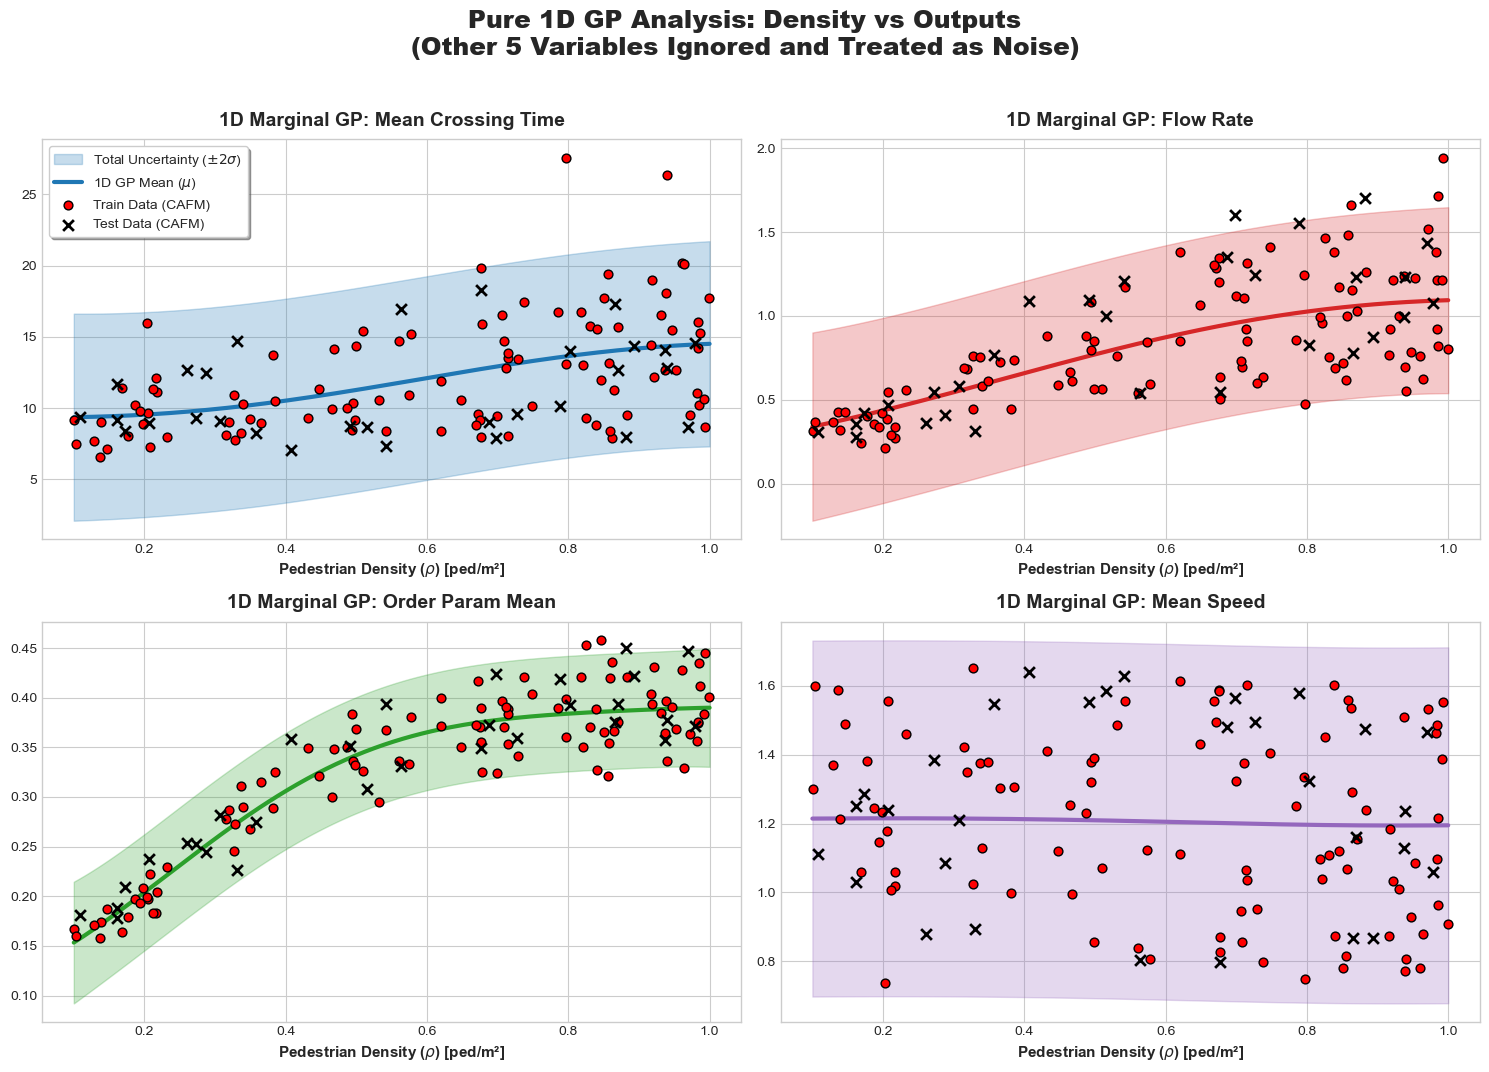

In [2]:
import numpy as np
import torch
import gpytorch
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import warnings

warnings.filterwarnings("ignore")
plt.style.use('seaborn-v0_8-whitegrid')

# ==========================================
# 1. 1D GPYTORCH KERNEL
# ==========================================
class Marginal1DGP(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        # RBF Kernel for smooth 1D mapping
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# ==========================================
# 2. LOAD DATA & EXTRACT ONLY DENSITY
# ==========================================
def run_1d_marginal_gp(data_path):
    print("="*70)
    print("🧠 TRAINING PURE 1D GP (DENSITY -> 4 OUTPUTS) 🧠")
    print("="*70)
    
    # Load the 3000 point dataset
    data = np.load(data_path)
    X_raw, Y_raw = data['X'], data['Y']
    param_names, output_names = data['param_names'], data['output_names']
    num_tasks = Y_raw.shape[1]
    
    # Clean NaNs
    valid_mask = ~np.isnan(Y_raw).any(axis=1)
    X_clean, Y_clean = X_raw[valid_mask], Y_raw[valid_mask]

    # EXTRACT ONLY DENSITY (Index 4)
    density_idx = list(param_names).index("density")
    X_density_only = X_clean[:, density_idx].reshape(-1, 1)

    # We select a subset so the plot is readable (100 Train, 30 Test)
    # If we plot all 3000, it becomes a solid block of ink.
    X_train, X_test, Y_train, Y_test = train_test_split(
        X_density_only, Y_clean, train_size=100, test_size=30, random_state=42
    )

    # Scaling
    scaler_X = StandardScaler()
    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)
    
    scaler_Y = StandardScaler()
    Y_train_scaled = scaler_Y.fit_transform(Y_train)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    train_x_t = torch.FloatTensor(X_train_scaled.flatten()).to(device)
    
    models, likelihoods = [], []
    
    # Train 4 Independent 1D GPs
    for i in range(num_tasks):
        train_y_t = torch.FloatTensor(Y_train_scaled[:, i]).to(device)
        
        # We allow the GP to learn the noise, because the other 5 missing variables 
        # will look like heavy "observation noise" to this 1D model.
        likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device)
        model = Marginal1DGP(train_x_t, train_y_t, likelihood).to(device)
        
        models.append(model)
        likelihoods.append(likelihood)

    model_list = gpytorch.models.IndependentModelList(*models)
    likelihood_list = gpytorch.likelihoods.LikelihoodList(*likelihoods)

    model_list.train()
    likelihood_list.train()
    
    optimizer = torch.optim.Adam(model_list.parameters(), lr=0.1)
    mll = gpytorch.mlls.SumMarginalLogLikelihood(likelihood_list, model_list)
    
    print("Training the 1D GPs...")
    epochs = 500 
    for i in range(epochs):
        optimizer.zero_grad()
        output = model_list(*[train_x_t for _ in range(num_tasks)])
        loss = -mll(output, [torch.FloatTensor(Y_train_scaled[:, t]).to(device) for t in range(num_tasks)])
        loss.backward()
        optimizer.step()

    # ==========================================
    # 3. SWEEP & PLOT THE UNCERTAINTY
    # ==========================================
    print("\nGenerating the 1D Uncertainty Plot...")
    model_list.eval()
    likelihood_list.eval()
    
    # Create a smooth density line from 0.1 to 1.0
    den_sweep = np.linspace(0.1, 1.0, 200).reshape(-1, 1)
    sweep_scaled_t = torch.FloatTensor(scaler_X.transform(den_sweep).flatten()).to(device)

    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        # Notice we call `likelihood_list` here to include the learned observation noise!
        sweep_preds = likelihood_list(*model_list(*[sweep_scaled_t for _ in range(num_tasks)]))

    fig, axes = plt.subplots(2, 2, figsize=(15, 11))
    axes = axes.flatten()
    plot_colors = ['#1f77b4', '#d62728', '#2ca02c', '#9467bd']

    for i in range(num_tasks):
        mean_scaled = sweep_preds[i].mean.cpu().numpy()
        std_scaled  = np.sqrt(sweep_preds[i].variance.cpu().numpy())

        mean_real = (mean_scaled * scaler_Y.scale_[i]) + scaler_Y.mean_[i]
        std_real  = std_scaled * scaler_Y.scale_[i] 

        ax = axes[i]
        
        # Plot the Uncertainty Band
        ax.fill_between(den_sweep.flatten(),
                        mean_real - 2*std_real,
                        mean_real + 2*std_real,
                        color=plot_colors[i], alpha=0.25, label=r'Total Uncertainty ($\pm 2\sigma$)')
        
        # Plot the GP Mean Line
        ax.plot(den_sweep.flatten(), mean_real, color=plot_colors[i], lw=3, label='1D GP Mean ($\mu$)')

        # Plot the Training Data (Red Dots)
        ax.scatter(X_train.flatten(), Y_train[:, i],
                   color='red', edgecolor='black', s=40, zorder=5, label='Train Data (CAFM)')
        
        # Plot the Test Data (Black X's)
        ax.scatter(X_test.flatten(), Y_test[:, i],
                   color='black', marker='x', s=60, lw=2, zorder=6, label='Test Data (CAFM)')

        # Formatting
        title_str = output_names[i].replace('_', ' ').title()
        ax.set_title(f"1D Marginal GP: {title_str}", fontsize=14, fontweight='bold', pad=10)
        ax.set_xlabel(r"Pedestrian Density ($\rho$) [ped/m²]", fontsize=11, fontweight='bold')
        
        if i == 0:
            ax.legend(loc='upper left', fontsize=10, frameon=True, shadow=True)

    plt.suptitle("Pure 1D GP Analysis: Density vs Outputs\n(Other 5 Variables Ignored and Treated as Noise)", 
                 fontsize=18, fontweight='black', y=0.97)
    plt.tight_layout(rect=[0, 0, 1, 0.95]) 
    
    save_file = "marginal_1d_gp_plot.png"
    plt.savefig(save_file, dpi=400, bbox_inches='tight')
    print(f"✅ Plot successfully saved to: {save_file}")
    plt.show()

if __name__ == "__main__":
    # Point to your actual dataset!
    DATA_PATH = r"D:\KIT\cafm_lhs_3000_active.npz"
    run_1d_marginal_gp(DATA_PATH)